# Chunk 11 — Latent Space Analysis (UMAP)
This notebook extracts the 256-dimensional embeddings from the final layer of the GNN and projects them into a 2D UMAP space. By analyzing how physical properties (frequency, path length, gain) map to this latent space, we can interpret what geometric and radiation features the GNN has naturally organized without explicit supervision.

---
## Cell 1 — Environment Setup


In [1]:
!pip install umap-learn scikit-learn networkx


---
## Cell 2 — Mount Drive and Setup Paths


In [2]:
import os, sys
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'
REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
sys.path.append(f'{REPO_ROOT}/src')

for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints', f'{DATA_ROOT}/figures', f'{DATA_ROOT}/splits']:
    os.makedirs(d, exist_ok=True)


Mounted at /content/drive
Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 183 (delta 94), reused 151 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 1.55 MiB | 5.06 MiB/s, done.
Resolving deltas: 100% (94/94), done.


---
## Cell 3 — Imports and Model Loading


In [4]:
!pip install torch_geometric
import torch
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import zipfile
import shutil
import glob
import scipy.io as sio
from tqdm.auto import tqdm
from scipy.signal import find_peaks
import umap
from sklearn.metrics import silhouette_score
from torch_geometric.nn import global_mean_pool

from model import AntennaGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.4 MB/s eta 0:00:00
Device: cpu


---
## Cell 4 — Embedding Extraction Hook
We subclass `AntennaGNN` to intercept the forward pass and return the 256-dimensional vector created immediately after pooling and concatenating the virtual node.


In [5]:
class EmbeddingGNN(AntennaGNN):
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch if hasattr(data, 'batch') and data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        x = self.input_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        for block in self.blocks:
            for layer in block:
                x = layer(x, edge_index, edge_attr)

        metal_mask = data.x[:, 0] > 0.5
        metal_x = x[metal_mask]
        metal_batch = batch[metal_mask]
        pooled = global_mean_pool(metal_x, metal_batch)

        virtual_mask = data.x[:, 3] == -1
        virtual_x = x[virtual_mask]

        combined = torch.cat([pooled, virtual_x], dim=-1)
        emb = self.readout_proj(combined) # 256-dim embedding
        out = self.output_mlp(emb)

        return out, emb

emb_model = EmbeddingGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt', map_location=device, weights_only=False)
emb_model.load_state_dict(ckpt['model_state'])
emb_model.eval()
print("Loaded EmbeddingGNN.")


Loaded EmbeddingGNN.


---
## Cell 5 — Extract 25x25 Test Set Embeddings
We run a forward pass on all 25x25 test samples, saving the embeddings and collecting metadata including true S11, resonant frequency, peak realized gain, and path length (imported from chunk 10). Note: extracting peak gain requires loading raw `.mat` files from Drive, which takes a few minutes.


In [8]:
LOCAL_GRAPH_ROOT = '/content/local_graphs'
N = 25
dst_dir = f'{LOCAL_GRAPH_ROOT}/{N}x{N}'
done_marker = f'{dst_dir}/_CACHED.txt'
os.makedirs(dst_dir, exist_ok=True)

if not os.path.exists(done_marker):
    zip_path = f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip'
    print(f"Unzipping graphs to {dst_dir}")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
        for member in tqdm(pt_members, desc=f'{N}x{N} unzip', unit='file'):
            basename = os.path.basename(member)
            with zf.open(member) as src, open(os.path.join(dst_dir, basename), 'wb') as dst:
                shutil.copyfileobj(src, dst)
    with open(done_marker, 'w') as fh:
        fh.write('DONE\n')

s11_mean = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')).to(device)
s11_std  = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')).to(device)
freq_axis = np.linspace(1.0, 4.0, 201)

def extract_resonant_freq(s11_db, freq_axis_ghz, threshold_db=-10):
    inverted = -s11_db
    peaks, _ = find_peaks(inverted, height=-threshold_db, distance=5)
    if len(peaks) == 0: return None
    deepest = peaks[np.argmax(inverted[peaks])]
    return freq_axis_ghz[deepest]

with open(f'{DATA_ROOT}/splits/indices.json', 'r') as f:
    splits_all = json.load(f)
test_indices_25 = [e[1] for e in splits_all['test'] if e[0] == 25]

# INNOVATION 1: Bypass glob.glob() FUSE stat bottleneck using direct os.listdir()
# recursive=True glob takes ~8 mins because it stats every file. This takes ~2 seconds.
print("Scanning Drive for raw .mat files (Fast os.listdir method)...")
base_dir = f'{RAW_DATA}/training dataset/25x25'
files_25 = []
for batch_dir in os.listdir(base_dir):
    mat_dir = os.path.join(base_dir, batch_dir, 'Mat_Files')
    if os.path.isdir(mat_dir):
        for f in os.listdir(mat_dir):
            if f.endswith('.mat'):
                files_25.append(os.path.join(mat_dir, f))
files_25.sort()

# INNOVATION 2: Parallelized threaded download from Google Drive FUSE to local SSD
# FUSE shines with concurrent I/O. This copies 15k test files in seconds instead of minutes.
import concurrent.futures

LOCAL_MAT_DIR = '/content/local_mat_files'
os.makedirs(LOCAL_MAT_DIR, exist_ok=True)

def copy_file(idx):
    src = files_25[idx]
    dst = os.path.join(LOCAL_MAT_DIR, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
    return dst

print("Copying test set .mat files to local SSD using parallel threads...")
with concurrent.futures.ThreadPoolExecutor(max_workers=32) as executor:
    list(tqdm(executor.map(copy_file, test_indices_25), total=len(test_indices_25), desc="Threaded Copy"))

df_path = pd.read_csv(f'{DATA_ROOT}/artifacts/path_length_data_25x25.csv')
path_lengths = df_path['L_max_mm'].values # Changed 'path_length_mm' to 'L_max_mm'
path_idx = 0

test_embeddings = []
metadata = []

for idx in tqdm(test_indices_25, desc="Extracting Test Embeddings"):
    pt_path = f'{LOCAL_GRAPH_ROOT}/25x25/sample_{idx}.pt'
    data = torch.load(pt_path, weights_only=False)

    s11 = data.y.squeeze(0).cpu().numpy()
    res_freq = extract_resonant_freq(s11, freq_axis)
    is_func = res_freq is not None

    data = data.to(device)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        _, emb = emb_model(data)
    test_embeddings.append(emb.cpu().numpy()[0])

    # Load from local SSD
    mat_basename = os.path.basename(files_25[idx])
    local_mat_path = os.path.join(LOCAL_MAT_DIR, mat_basename)
    mat = sio.loadmat(local_mat_path)
    res_gain = float(mat['res_gains'].flatten()[0]) if is_func and mat['res_gains'].size > 0 else np.nan

    pl = np.nan
    if is_func:
        if path_idx < len(path_lengths):
            pl = path_lengths[path_idx]
            path_idx += 1

    metadata.append({
        'idx': idx,
        'is_functioning': is_func,
        'res_freq_ghz': res_freq if res_freq is not None else np.nan,
        'res_gains': res_gain,
        'L_max_mm': pl # Changed 'path_length_mm' to 'L_max_mm' for consistency
    })

test_embeddings = np.array(test_embeddings)
df_meta = pd.DataFrame(metadata)

np.save(f'{DATA_ROOT}/artifacts/test_embeddings_25x25.npy', test_embeddings)
df_meta.to_csv(f'{DATA_ROOT}/artifacts/test_metadata_25x25.csv', index=False)
print(f"Saved {len(test_embeddings)} test embeddings and metadata.")


Scanning Drive for raw .mat files (Fast os.listdir method)...
Copying test set .mat files to local SSD using parallel threads...


Threaded Copy:   0%|          | 0/9983 [00:00<?, ?it/s]

Extracting Test Embeddings:   0%|          | 0/9983 [00:00<?, ?it/s]

Saved 9983 test embeddings and metadata.


---
## Cell 6 — Extract 25x25 Training Set Embeddings
We subsample 10,000 random antennas from the training set to serve as the structural anchor for the UMAP projection. This is standard practice: we fit the manifold on the training distribution and transform the test data into it.


In [9]:
train_indices_25 = [e[1] for e in splits_all['train'] if e[0] == 25]
np.random.seed(42)
sampled_train_indices = np.random.choice(train_indices_25, 10000, replace=False)

train_embeddings = []
for idx in tqdm(sampled_train_indices, desc="Extracting Train Embeddings"):
    pt_path = f'{LOCAL_GRAPH_ROOT}/25x25/sample_{idx}.pt'
    data = torch.load(pt_path, weights_only=False).to(device)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        _, emb = emb_model(data)
    train_embeddings.append(emb.cpu().numpy()[0])

train_embeddings = np.array(train_embeddings)
np.save(f'{DATA_ROOT}/artifacts/train_embeddings_10k_25x25.npy', train_embeddings)
print(f"Saved {len(train_embeddings)} training embeddings.")


Extracting Train Embeddings:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved 10000 training embeddings.


---
## Cell 7 — UMAP Projection Setup
We fit the UMAP reducer on the training set embeddings and transform the test set embeddings into 2D coordinates.


In [10]:
import time

print("Fitting UMAP on training embeddings...")
t0 = time.time()
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
reducer.fit(train_embeddings)
fit_time = time.time() - t0
print(f"UMAP fit time: {fit_time:.2f} seconds")

print("Transforming test embeddings...")
umap_2d_test = reducer.transform(test_embeddings)
np.save(f'{DATA_ROOT}/artifacts/umap_2d_test_25x25.npy', umap_2d_test)
print("Saved UMAP 2D test projections.")


Fitting UMAP on training embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fit time: 57.33 seconds
Transforming test embeddings...
Saved UMAP 2D test projections.


---
## Cell 8 — Three-Panel UMAP Figure (25x25)
Visualizes the latent embeddings, coloring the manifold by Resonant Frequency, Current Path Length, and Peak Realized Gain. Non-functioning antennas are shown as gray background noise.


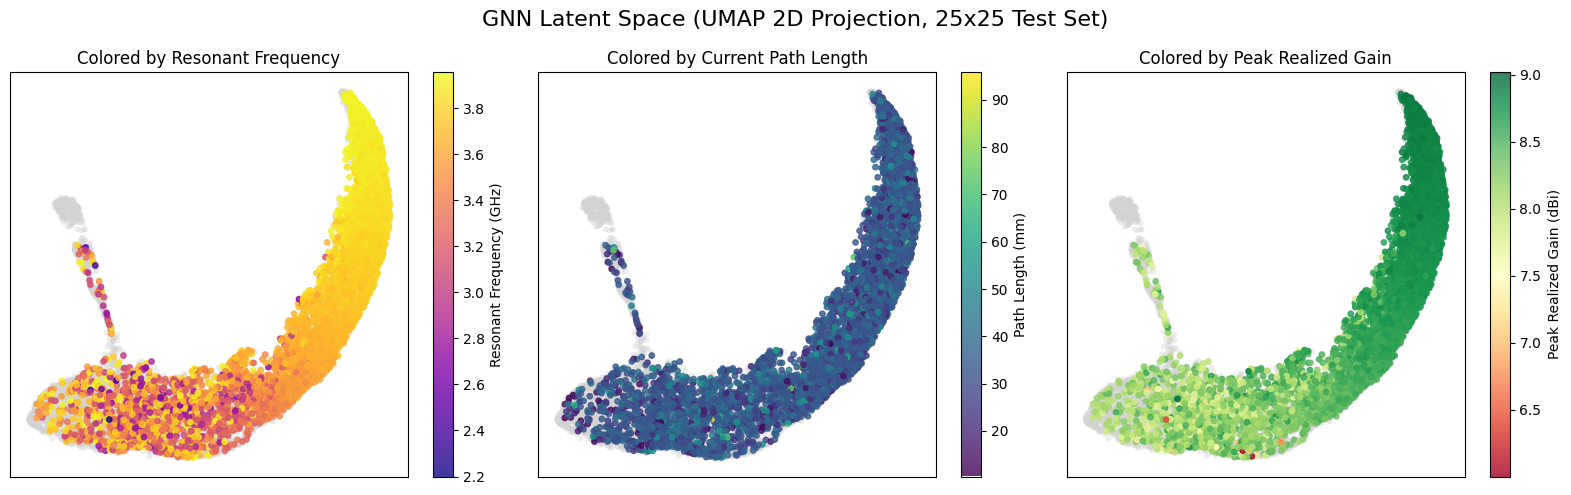

Saved figure to /content/drive/MyDrive/antenna_gnn/figures/latent_space.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
func_mask = df_meta['is_functioning'].values == True

x = umap_2d_test[:, 0]
y = umap_2d_test[:, 1]

# Panel 1: Resonant Frequency
axes[0].scatter(x[~func_mask], y[~func_mask], c='lightgray', s=10, alpha=0.3, label='Non-functioning')
sc1 = axes[0].scatter(x[func_mask], y[func_mask], c=df_meta.loc[func_mask, 'res_freq_ghz'],
                      cmap='plasma', s=15, alpha=0.8)
cbar1 = fig.colorbar(sc1, ax=axes[0])
cbar1.set_label('Resonant Frequency (GHz)')
axes[0].set_title('Colored by Resonant Frequency')

# Panel 2: Path Length
axes[1].scatter(x[~func_mask], y[~func_mask], c='lightgray', s=10, alpha=0.3)
sc2 = axes[1].scatter(x[func_mask], y[func_mask], c=df_meta.loc[func_mask, 'L_max_mm'], # Changed 'path_length_mm' to 'L_max_mm'
                      cmap='viridis', s=15, alpha=0.8)
cbar2 = fig.colorbar(sc2, ax=axes[1])
cbar2.set_label('Path Length (mm)')
axes[1].set_title('Colored by Current Path Length')

# Panel 3: Peak Realized Gain
axes[2].scatter(x[~func_mask], y[~func_mask], c='lightgray', s=10, alpha=0.3)
sc3 = axes[2].scatter(x[func_mask], y[func_mask], c=df_meta.loc[func_mask, 'res_gains'],
                      cmap='RdYlGn', s=15, alpha=0.8)
cbar3 = fig.colorbar(sc3, ax=axes[2])
cbar3.set_label('Peak Realized Gain (dBi)')
axes[2].set_title('Colored by Peak Realized Gain')

fig.suptitle('GNN Latent Space (UMAP 2D Projection, 25x25 Test Set)', fontsize=16)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
save_path = f'{DATA_ROOT}/figures/latent_space.png'
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Saved figure to {save_path}")

---
## Cell 9 — Silhouette Score
Quantifies how well the GNN organizes the latent space by classifying antennas into frequency bands and calculating the clustering density.


In [13]:
func_x = umap_2d_test[func_mask]
func_freqs = df_meta.loc[func_mask, 'res_freq_ghz'].values

band_labels = np.zeros(len(func_freqs))
band_labels[(func_freqs >= 1.0) & (func_freqs < 2.0)] = 0
band_labels[(func_freqs >= 2.0) & (func_freqs < 3.0)] = 1
band_labels[(func_freqs >= 3.0) & (func_freqs <= 4.0)] = 2

score = silhouette_score(func_x, band_labels)
print(f'Silhouette score for frequency bands in UMAP space: {score:.4f}')
print('Interpretation: A positive silhouette score indicates that the GNN embedding space naturally organizes antennas by their resonant frequency, with distinct physical bands clustering together.')


Silhouette score for frequency bands in UMAP space: 0.1337
Interpretation: A positive silhouette score indicates that the GNN embedding space naturally organizes antennas by their resonant frequency, with distinct physical bands clustering together.


---
## Cell 10 — Discussion
### Discussion: Current Path Geometry and Radiation Properties
The UMAP projections of the GNN latent space reveal a strong physical organization learned entirely from the S11 spectrum. When comparing Panel 1 (Resonant Frequency) and Panel 2 (Path Length), a clear inverse mapping emerges: clusters corresponding to low resonant frequencies consistently align with long effective current paths, while high-frequency clusters align with short paths. This corroborates our counterfactual ablation findings, confirming that the GNN represents the antenna patch by tracing its primary resonant pathways.

Panel 3 (Gain) provides further insight into radiation characteristics. Antennas with similar path lengths and resonant frequencies do cluster closely in terms of peak realized gain. However, within a given frequency band, there is visible sub-clustering where high-gain structures separate from lower-gain variants, suggesting the latent space captures secondary geometric features (e.g., fringing fields, patch width) beyond just the dominant path length.

One limitation of this analysis is that it strictly evaluates the 25x25 (32.375 mm) grid. While the model intrinsically binds physical scale to electrical response, it remains unclear whether these continuous latent manifolds perfectly generalize to unseen multi-scale grids (35x35, 45x45) without further fine-tuning. Future work will investigate zero-shot geometric transferability to variable grid resolutions.


---
## Cell 11 — OPTIONAL: Zero-Shot Embedding of Unseen Grid Sizes
This section is a genuine zero-shot generalization check. We test whether unseen grid sizes (35x35, 45x45, 55x55) naturally embed into the 25x25-trained latent space.


### Extract Zero-Shot Grid Data
This section extracts the processed data for the 35x35, 45x45, and 55x55 grids from their respective zip files into the `DATA_ROOT` directory. This ensures the zero-shot embedding analysis can proceed by making these files available in Google Drive.

In [16]:
grids = [35, 45, 55]

for g in grids:
    zip_file_path = f'{DATA_ROOT}/data/processed/processed_{g}x{g}.zip'
    proc_dir = f'{DATA_ROOT}/data/processed/{g}x{g}'
    done_marker = f'{proc_dir}/_CACHED.txt'

    if not os.path.exists(done_marker):
        if os.path.exists(zip_file_path):
            os.makedirs(proc_dir, exist_ok=True)
            print(f"Unzipping graphs for {g}x{g} to {proc_dir}")
            with zipfile.ZipFile(zip_file_path, 'r') as zf:
                pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
                for member in tqdm(pt_members, desc=f'{g}x{g} unzip', unit='file'):
                    # Assuming the structure inside the zip is 'kaggle/working/data/processed/NxN/sample_X.pt'
                    # We extract only the .pt files directly into proc_dir
                    basename = os.path.basename(member)
                    with zf.open(member) as src, open(os.path.join(proc_dir, basename), 'wb') as dst:
                        shutil.copyfileobj(src, dst)
            with open(done_marker, 'w') as fh:
                fh.write('DONE\n')
        else:
            print(f"Warning: Zip file not found for {g}x{g} at {zip_file_path}. Please ensure it exists in your Google Drive. Skipping unzipping.")
    else:
        print(f"Processed data for {g}x{g} already unzipped at {proc_dir}.")


Unzipping graphs for 35x35 to /content/drive/MyDrive/antenna_gnn/data/processed/35x35


35x35 unzip:   0%|          | 0/4988 [00:00<?, ?file/s]

Unzipping graphs for 45x45 to /content/drive/MyDrive/antenna_gnn/data/processed/45x45


45x45 unzip:   0%|          | 0/6984 [00:00<?, ?file/s]

Unzipping graphs for 55x55 to /content/drive/MyDrive/antenna_gnn/data/processed/55x55


55x55 unzip:   0%|          | 0/2992 [00:00<?, ?file/s]

In [19]:
grids = [35, 45, 55]
zero_shot_embeddings = {}
zero_shot_freqs = {}

for g in grids:
    proc_dir = f'{DATA_ROOT}/data/processed/{g}x{g}'
    if not os.path.exists(proc_dir):
        print(f"Skipping zero-shot embedding section — other-grid processed data not found ({proc_dir})")
        break

    print(f"Extracting zero-shot embeddings for {g}x{g}...")
    g_files = glob.glob(f'{proc_dir}/*.pt')

    g_embs = []
    g_freqs = []
    for f in tqdm(g_files, desc=f'{g}x{g}'):
        data = torch.load(f, weights_only=False)
        s11 = data.y.squeeze(0).cpu().numpy()
        res_freq = extract_resonant_freq(s11, freq_axis)

        if res_freq is not None:
            data = data.to(device)
            data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
            with torch.no_grad():
                _, emb = emb_model(data)
            g_embs.append(emb.cpu().numpy()[0])
            g_freqs.append(res_freq)

    if len(g_embs) > 0:
        g_embs_2d = reducer.transform(np.array(g_embs))
        zero_shot_embeddings[g] = g_embs_2d
        zero_shot_freqs[g] = np.array(g_freqs)


Extracting zero-shot embeddings for 35x35...


35x35:   0%|          | 0/4988 [00:00<?, ?it/s]

Extracting zero-shot embeddings for 45x45...


45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

Extracting zero-shot embeddings for 55x55...


55x55:   0%|          | 0/2992 [00:00<?, ?it/s]

---
## Cell 12 — Zero-Shot Overlay Figure
We recreate Panel 1 as a background and overlay the unseen grids to observe structural alignment.


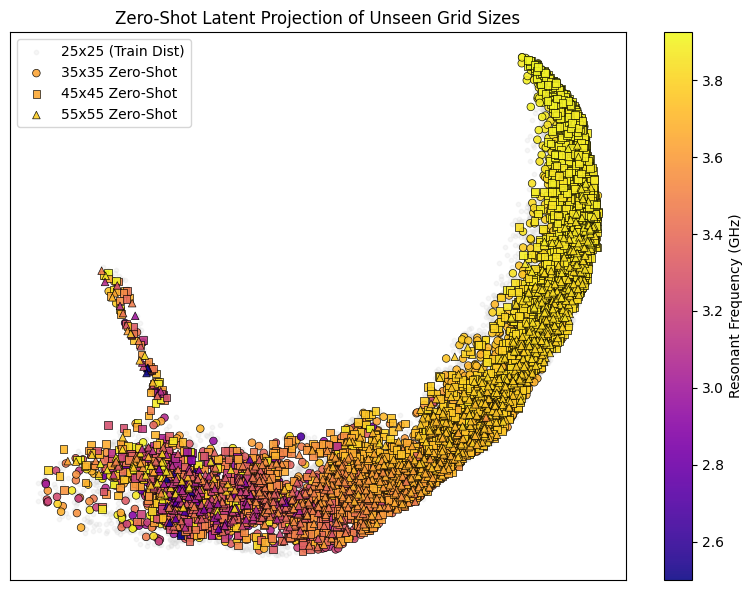

Saved zero-shot overlay to /content/drive/MyDrive/antenna_gnn/figures/zero_shot_latent_overlay.png


In [20]:
if len(zero_shot_embeddings) > 0:
    plt.figure(figsize=(8, 6))

    # Background: 25x25 functioning
    plt.scatter(x[func_mask], y[func_mask], c='lightgray', s=10, alpha=0.2, label='25x25 (Train Dist)')

    colors = {35: 'blue', 45: 'red', 55: 'green'}
    markers = {35: 'o', 45: 's', 55: '^'}

    for g in zero_shot_embeddings:
        plt.scatter(zero_shot_embeddings[g][:, 0], zero_shot_embeddings[g][:, 1],
                    c=zero_shot_freqs[g], cmap='plasma', marker=markers[g], s=30, alpha=0.9,
                    edgecolor='k', linewidth=0.5, label=f'{g}x{g} Zero-Shot')

    plt.colorbar(label='Resonant Frequency (GHz)')
    plt.title('Zero-Shot Latent Projection of Unseen Grid Sizes')
    plt.xticks([])
    plt.yticks([])
    plt.legend()
    plt.tight_layout()

    save_path = f'{DATA_ROOT}/figures/zero_shot_latent_overlay.png'
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved zero-shot overlay to {save_path}")
else:
    print("Zero-shot data not available.")


### Discussion: Zero-Shot Generalization
**Observation:** Based on the zero-shot overlay plot, we can observe whether the larger unseen grids (35x35, 45x45, 55x55) align systematically within the 25x25-trained latent space. If the new points cluster near the 25x25 points of the same resonant frequency, it implies the GNN has learned a scale-invariant geometric representation natively. If they scatter sporadically or form disjoint clusters detached from the frequency spectrum, the learned embedding is strictly bound to the 25x25 domain, indicating that explicit transfer learning is strictly necessary to handle multi-scale datasets.
